<a href="https://colab.research.google.com/github/maialonso/TP1-TDVI/blob/main/TP1-TDVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import seaborn as sns



# P1: Ejercicio 1

## Descripción de los datos y del problema

El dataset **Telco Customer Churn** contiene información sobre clientes de una empresa de telecomunicaciones. Cada fila representa a un cliente y las columnas describen características demográficas, servicios contratados, modalidad de pago, antigüedad y comportamiento respecto de la permanencia en la empresa.

- **gender**: género del cliente.
- **SeniorCitizen**: indica si el cliente es una persona mayor.
- **Partner**: indica si el cliente tiene pareja.
- **Dependents**: indica si el cliente tiene personas a cargo.
- **tenure**: antigüedad del cliente en la empresa.
- **PhoneService**: indica si cuenta con servicio telefónico.
- **MultipleLines**: indica si posee múltiples líneas telefónicas.
- **InternetService**: indica el tipo de servicio de internet contratado.
- **OnlineSecurity**: indica si cuenta con servicio de seguridad online.
- **OnlineBackup**: indica si cuenta con servicio de respaldo online.
- **DeviceProtection**: indica si posee protección para sus dispositivos.
- **TechSupport**: indica si cuenta con soporte técnico.
- **StreamingTV**: indica si tiene contratado el servicio de streaming de televisión.
- **StreamingMovies**: indica si tiene contratado el servicio de streaming de películas.
- **Contract**: indica la modalidad o duración del contrato.
- **PaperlessBilling**: indica si utiliza facturación electrónica.
- **PaymentMethod**: indica el método de pago utilizado.
- **MonthlyCharges**: representa el cargo mensual del cliente.
- **TotalCharges**: representa el monto total acumulado facturado al cliente.
- **Churn**: indica si el cliente abandonó o no el servicio.


El objetivo es desarrollar un modelo de clasificación que permita predecir si un cliente abandonará el servicio a partir de sus características y de su relación actual con la empresa.

La variable objetivo es `Churn`, que presenta dos posibles resultados:
- `Yes`: el cliente abandonó el servicio.
- `No`: el cliente permaneció en el servicio.

Contar con una estimación anticipada del riesgo de abandono puede permitir a la empresa identificar clientes con mayor probabilidad de fuga y orientar acciones de retención de manera más eficiente.

In [2]:
churn = pd.read_csv("churn.csv")
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Estadísticas descriptivas

Como parte del análisis exploratorio, calculamos distintos ratios de abandono para varias características de los clientes. Analizamos una gran cantidad de variables ya que todavía no sabíamos cuáles podían mostrar una mayor relación con `Churn`. Esto nos permitió comparar los distintos grupos e identificar los patrones más relevantes.

In [3]:
# RATIO HOMBRES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
male = churn['gender'] == 'Male'
male_y= churn_y & male
ratio_cantidad_hombres = male_y.sum() / male.sum()

ratio_cantidad_hombres

np.float64(0.2616033755274262)

In [4]:
# RATIO MUJERES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
female = churn['gender'] == 'Female'
female_y = churn_y & female
ratio_cantidad_mujeres = female_y.sum() / female.sum()

ratio_cantidad_mujeres

np.float64(0.26920871559633025)

In [5]:
# RATIO SENIORS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
senior = churn['SeniorCitizen'] == 1
senior_y = churn_y & senior
ratio_cantidad_seniors = senior_y.sum() / senior.sum()

ratio_cantidad_seniors

np.float64(0.4168126094570928)

In [6]:
# RATIO PERSONAS CON PAREJA QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
partner = churn['Partner'] == 'Yes'
partner_y = churn_y & partner
ratio_cantidad_partner = partner_y.sum() / partner.sum()

ratio_cantidad_partner

np.float64(0.1966490299823633)

In [7]:
# RATIO PERSONAS CON DEPENDIENTES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
dependents = churn['Dependents'] == 'Yes'
dependents_y = churn_y & dependents
ratio_cantidad_dependents = dependents_y.sum() / dependents.sum()

ratio_cantidad_dependents

np.float64(0.15450236966824646)

In [8]:
# RATIO PERSONAS CON SERVICIO TELEFONICO QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
phone_service = churn['PhoneService'] == 'Yes'
phone_service_y = churn_y & phone_service
ratio_cantidad_phone_service = phone_service_y.sum() / phone_service.sum()

ratio_cantidad_phone_service

np.float64(0.2670963684955196)

In [9]:
# RATIO PERSONAS CON MULTIPLES LINEAS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
multiple_lines = churn['MultipleLines'] == 'Yes'
multiple_lines_y = churn_y & multiple_lines
ratio_cantidad_multiple_lines = multiple_lines_y.sum() / multiple_lines.sum()

ratio_cantidad_multiple_lines


np.float64(0.286098956580276)

In [10]:
# RATIO PERSONAS SIN MULTIPLES LINEAS QUE ABANDONAN

no_multiple_lines = churn['MultipleLines'] == 'No'
no_multiple_lines_y = churn_y & no_multiple_lines
ratio_cantidad_no_multiple_lines = no_multiple_lines_y.sum() / no_multiple_lines.sum()

ratio_cantidad_no_multiple_lines

np.float64(0.2504424778761062)

In [11]:
# RATIO PERSONAS CON INTERNET DSL QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
internet_dsl = churn['InternetService'] == 'DSL'
internet_dsl_y = churn_y & internet_dsl
ratio_cantidad_internet_dsl = internet_dsl_y.sum() / internet_dsl.sum()

ratio_cantidad_internet_dsl

np.float64(0.1895910780669145)

In [12]:
# RATIO PERSONAS CON FIBRA OPTICA QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
internet_fiber = churn['InternetService'] == 'Fiber optic'
internet_fiber_y = churn_y & internet_fiber
ratio_cantidad_internet_fiber = internet_fiber_y.sum() / internet_fiber.sum()

ratio_cantidad_internet_fiber

np.float64(0.4189276485788114)

In [13]:
# RATIO PERSONAS SIN SERVICIO DE INTERNET QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
no_internet = churn['InternetService'] == 'No'
no_internet_y = churn_y & no_internet
ratio_cantidad_no_internet = no_internet_y.sum() / no_internet.sum()

ratio_cantidad_no_internet

np.float64(0.07404980340760157)

In [14]:
# RATIO PERSONAS SIN SERVICIO DE INTERNET QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
no_internet = churn['InternetService'] == 'No'
no_internet_y = churn_y & no_internet
ratio_cantidad_no_internet = no_internet_y.sum() / no_internet.sum()

ratio_cantidad_no_internet

np.float64(0.07404980340760157)

In [15]:
# RATIO PERSONAS CON ONLINE BACKUP QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
online_backup = churn['OnlineBackup'] == 'Yes'
online_backup_y = churn_y & online_backup
ratio_cantidad_online_backup = online_backup_y.sum() / online_backup.sum()

ratio_cantidad_online_backup

np.float64(0.21531494442157267)

In [16]:
# RATIO PERSONAS CON DEVICE PROTECTION QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
device_protection = churn['DeviceProtection'] == 'Yes'
device_protection_y = churn_y & device_protection
ratio_cantidad_device_protection = device_protection_y.sum() / device_protection.sum()

ratio_cantidad_device_protection

np.float64(0.2250206440957886)

In [17]:
# RATIO PERSONAS CON TECH SUPPORT QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
tech_support = churn['TechSupport'] == 'Yes'
tech_support_y = churn_y & tech_support
ratio_cantidad_tech_support = tech_support_y.sum() / tech_support.sum()

ratio_cantidad_tech_support

np.float64(0.15166340508806261)

In [18]:
# RATIO PERSONAS CON TECH SUPPORT QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
tech_support = churn['TechSupport'] == 'Yes'
tech_support_y = churn_y & tech_support
ratio_cantidad_tech_support = tech_support_y.sum() / tech_support.sum()

ratio_cantidad_tech_support

np.float64(0.15166340508806261)

In [19]:
# RATIO PERSONAS CON STREAMING MOVIES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
streaming_movies = churn['StreamingMovies'] == 'Yes'
streaming_movies_y = churn_y & streaming_movies
ratio_cantidad_streaming_movies = streaming_movies_y.sum() / streaming_movies.sum()

ratio_cantidad_streaming_movies

np.float64(0.29941434846266474)

In [20]:
# RATIO PERSONAS CON CONTRATO MES A MES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
month_to_month = churn['Contract'] == 'Month-to-month'
month_to_month_y = churn_y & month_to_month
ratio_cantidad_month_to_month = month_to_month_y.sum() / month_to_month.sum()

ratio_cantidad_month_to_month

np.float64(0.4270967741935484)

In [21]:
# RATIO PERSONAS CON CONTRATO DE UN AÑO QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
one_year = churn['Contract'] == 'One year'
one_year_y = churn_y & one_year
ratio_cantidad_one_year = one_year_y.sum() / one_year.sum()

ratio_cantidad_one_year

np.float64(0.11269517990495587)

In [22]:
# RATIO PERSONAS CON CONTRATO DE DOS AÑOS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
two_year = churn['Contract'] == 'Two year'
two_year_y = churn_y & two_year
ratio_cantidad_two_year = two_year_y.sum() / two_year.sum()

ratio_cantidad_two_year

np.float64(0.02831858407079646)

In [23]:
# RATIO PERSONAS CON PAPERLESS BILLING QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
paperless_billing = churn['PaperlessBilling'] == 'Yes'
paperless_billing_y = churn_y & paperless_billing
ratio_cantidad_paperless_billing = paperless_billing_y.sum() / paperless_billing.sum()

ratio_cantidad_paperless_billing

np.float64(0.33565092304003835)

In [24]:
# RATIO PERSONAS CON ELECTRONIC CHECK QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
electronic_check = churn['PaymentMethod'] == 'Electronic check'
electronic_check_y = churn_y & electronic_check
ratio_cantidad_electronic_check = electronic_check_y.sum() / electronic_check.sum()

ratio_cantidad_electronic_check

np.float64(0.4528541226215645)

In [25]:
# RATIO PERSONAS CON MAILED CHECK QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
mailed_check = churn['PaymentMethod'] == 'Mailed check'
mailed_check_y = churn_y & mailed_check
ratio_cantidad_mailed_check = mailed_check_y.sum() / mailed_check.sum()

ratio_cantidad_mailed_check

np.float64(0.19106699751861042)

In [26]:
# RATIO PERSONAS CON BANK TRANSFER AUTOMATIC QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
bank_transfer = churn['PaymentMethod'] == 'Bank transfer (automatic)'
bank_transfer_y = churn_y & bank_transfer
ratio_cantidad_bank_transfer = bank_transfer_y.sum() / bank_transfer.sum()

ratio_cantidad_bank_transfer

np.float64(0.16709844559585493)

In [27]:
# RATIO PERSONAS CON CREDIT CARD AUTOMATIC QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
credit_card = churn['PaymentMethod'] == 'Credit card (automatic)'
credit_card_y = churn_y & credit_card
ratio_cantidad_credit_card = credit_card_y.sum() / credit_card.sum()

ratio_cantidad_credit_card

np.float64(0.15243101182654403)

## Visualización de ratios

### Visualización 1: distribución general de `Churn`

Decidimos realizar este gráfico para observar cómo se distribuye `Churn` en el dataset y conocer la proporción de clientes que abandonan el servicio frente a los que permanecen. Esto también nos permite identificar si existe un desbalance entre ambas clases.

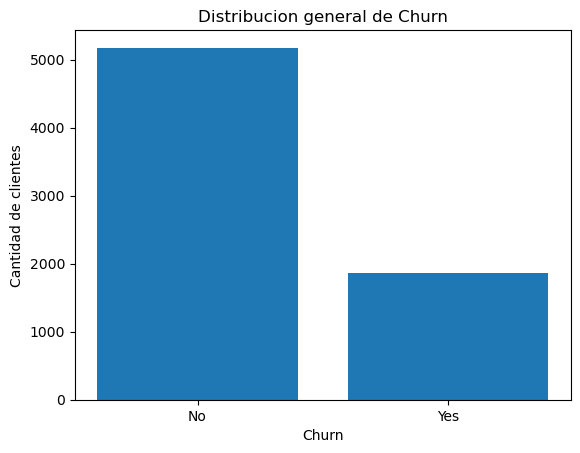

In [28]:

churn_counts = churn['Churn'].value_counts()
plt.bar(churn_counts.index, churn_counts.values)
plt.title('Distribucion general de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

Se observa que aproximadamente el 73,5% de los clientes permanece en el servicio, mientras que el 26,5% lo abandona. Esto muestra un desbalance entre las dos clases de `Churn`, con una mayor cantidad de clientes que no abandonan.

### Visualización 2: relación entre antigüedad y abandono del cliente

Como segunda visualización, analizamos la relación entre la antigüedad de los clientes y `Churn`, para observar si existen diferencias entre quienes abandonan el servicio y quienes permanecen.

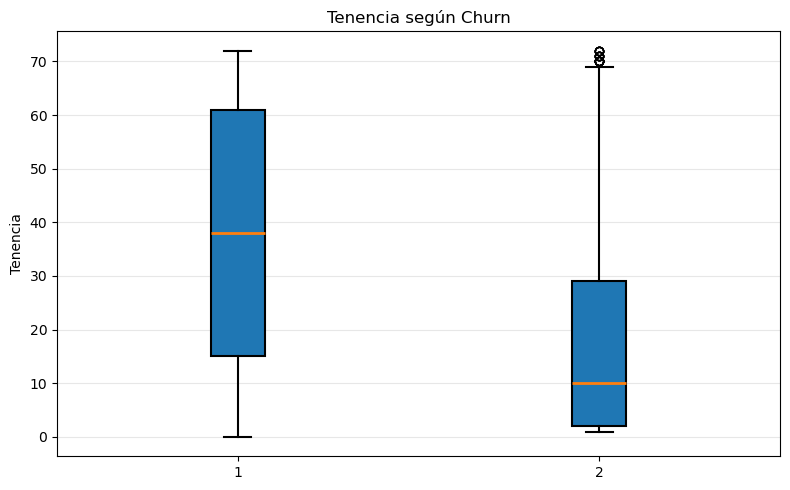

In [29]:
#Grafico boxplot tenencia de los que dejaron vs los que no dejaron

import matplotlib.pyplot as plt

churn_si = churn[churn['Churn'] == 'Yes']['tenure']

churn_no = churn[churn['Churn'] == 'No']['tenure']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [churn_no, churn_si],
    label=['No dejaron', 'Dejaron'],
    patch_artist=True,
    medianprops={'linewidth': 2},
    boxprops={'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5},
    capprops={'linewidth': 1.5}
)

plt.ylabel('Tenencia')
plt.title('Tenencia según Churn')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Se observa que los clientes que abandonan el servicio tienden a tener una menor antigüedad que aquellos que permanecen. Esto sugiere que `tenure` podría ser una variable relevante para predecir `Churn`.


### Visualización 3: ratio de abandono según tipo de contrato

Como en la visualización anterior observamos que los clientes con mayor antigüedad tienden a abandonar menos el servicio, decidimos analizar si la duración del contrato también presenta una relación con `Churn`. Para eso, comparamos la proporción de abandono entre los distintos tipos de contrato.

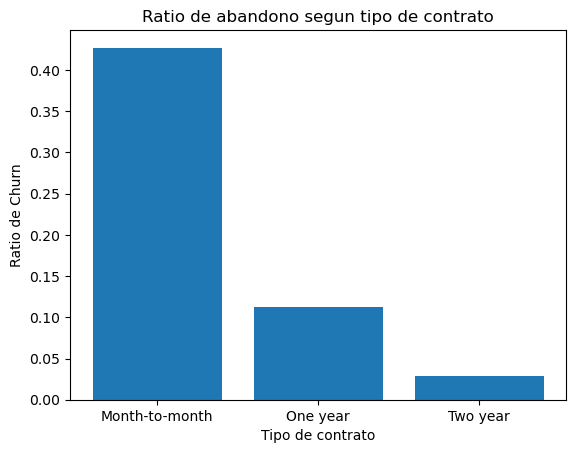

In [30]:
# VISUALIZACION 2: RATIO DE ABANDONO SEGUN TIPO DE CONTRATO

tipos_contrato = ['Month-to-month', 'One year', 'Two year']
ratios_contrato = [
    ratio_cantidad_month_to_month,
    ratio_cantidad_one_year,
    ratio_cantidad_two_year
]
plt.bar(tipos_contrato, ratios_contrato)
plt.title('Ratio de abandono segun tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Ratio de Churn')
plt.show()

Se observa que los clientes con contratos mes a mes presentan la mayor tasa de abandono, mientras que esta disminuye en los contratos de mayor duración. Esto sugiere que el tipo de contrato podría estar relacionado con `Churn`.

# P1 Ejercicio 2

## Tratamiento de valores faltantes

In [31]:
churn.isna().mean()

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.001562
Churn               0.000000
dtype: float64

Solo se observan valores faltantes en la columna `TotalCharges`. Dado que representan una proporción muy pequeña del total de observaciones, decidimos eliminar esas filas para evitar que afecten el análisis y el entrenamiento del modelo.

In [32]:
churn = churn.dropna(subset=["TotalCharges"])
churn.isna().mean()

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

## Transformación de variables categóricas


Transformamos las variables binarias a `0` y `1` para que puedan ser utilizadas como datos numéricos por el modelo.

In [33]:

churn['gender'] = churn['gender'].apply(lambda d: 1 if d == 'Male' else 0)
churn['Partner'] = churn['Partner'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['PhoneService'] = churn['PhoneService'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['PaperlessBilling'] = churn['PaperlessBilling'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['Churn'] = churn['Churn'].apply(lambda d: 1 if d == 'Yes' else 0)
churn.dtypes

customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents           object
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Algunas variables presentan tres categorías: `Yes`, `No` y `No internet service`. Decidimos agrupar `No` y `No internet service`, ya que en ambos casos el cliente no cuenta con ese servicio específico. De esta forma, tratamos estas variables como binarias.

In [34]:
churn['MultipleLines'] = churn['MultipleLines'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['OnlineSecurity'] = churn['OnlineSecurity'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['OnlineBackup'] = churn['OnlineBackup'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['DeviceProtection'] = churn['DeviceProtection'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['TechSupport'] = churn['TechSupport'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['StreamingTV'] = churn['StreamingTV'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['StreamingMovies'] = churn['StreamingMovies'].apply(lambda d: 1 if d == 'Yes' else 0)
churn.dtypes

customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents           object
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## Escalado de variables numéricas

Antes del escalado, observamos la distribución de las variables numéricas mediante boxplots para identificar posibles valores atípicos.

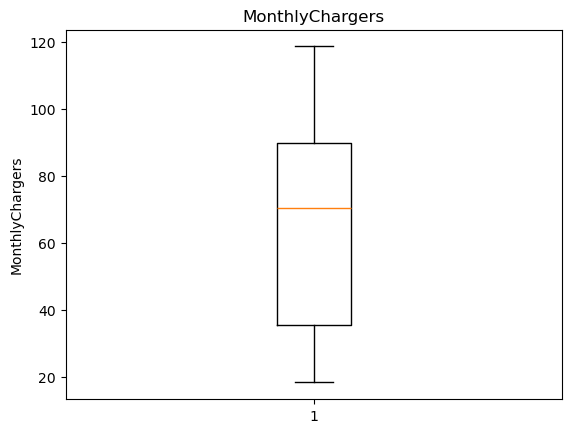

In [35]:
import matplotlib.pyplot as plt

plt.boxplot(churn['MonthlyCharges'])
plt.ylabel('MonthlyChargers')
plt.title('MonthlyChargers')
plt.show()

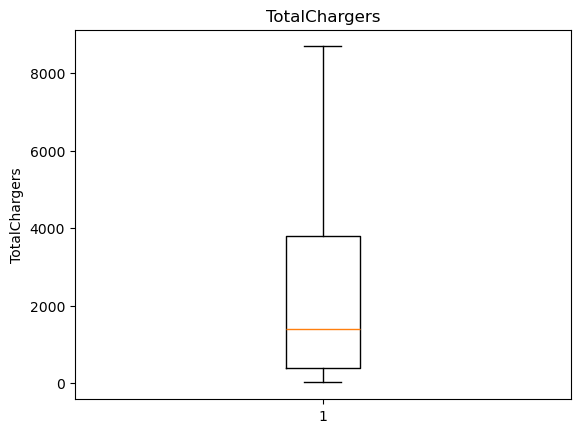

In [36]:
plt.boxplot(churn['TotalCharges'])
plt.ylabel('TotalChargers')
plt.title('TotalChargers')
plt.show()

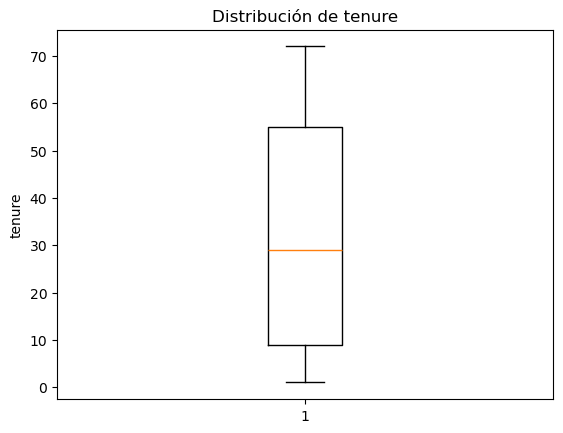

In [37]:
plt.boxplot(churn['tenure'])

plt.ylabel('tenure')
plt.title('Distribución de tenure')

plt.show()

Escalamos únicamente las variables numéricas no binarias mediante `StandardScaler`, para que queden en escalas comparables y evitar que las diferencias de magnitud entre ellas influyan en el modelo. Las variables binarias se mantienen como `0` y `1`, ya que no representan magnitudes continuas que sea necesario estandarizar.

El escalado no elimina ni modifica la presencia de valores atípicos, sino que transforma los valores a partir de la media y el desvío estándar de cada variable.

In [38]:

X = churn.drop(columns='Churn')
y = churn['Churn']

variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender','SeniorCitizen','Partner','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']

# Train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


## Orden de las operaciones y prevención de Data Leakage

El `Train/Test Split` debe realizarse antes del escalado y de cualquier imputación que requiera obtener información de los datos. Una vez separados los conjuntos, estas transformaciones deben ajustarse únicamente utilizando los datos de entrenamiento y luego aplicarse al conjunto de testeo.

Si se realizaran antes de la división, se estaría utilizando información del conjunto de testeo para preparar los datos de entrenamiento, generando Data Leakage. Esto haría que la evaluación del modelo no refleje correctamente su desempeño frente a datos que nunca vio.

En nuestro caso no fue necesario realizar una imputación, ya que la proporción de valores faltantes en `TotalCharges` era muy pequeña y decidimos eliminar esas observaciones. Si hubiéramos optado por imputarlos utilizando, por ejemplo, la media o la mediana, ese valor debería haberse calculado únicamente a partir del conjunto de entrenamiento.


# P1 Ejercicio 3

## Implementación de K-Fold Cross-Validation

In [39]:
def evaluar_knn(X_train, y_train, X_val, y_val, 
                n_neighbors=5, metric='minkowski', p=2, weights='uniform'):

    modelo = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p,
        weights=weights
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    resultados = {
        "k": n_neighbors,
        "metric": metric,
        "p": p,
        "weights": weights,
        "acc_train": accuracy_score(y_train, pred_train),
        "acc_val": accuracy_score(y_val, pred_val),
        "bacc_train": balanced_accuracy_score(y_train, pred_train),
        "bacc_val": balanced_accuracy_score(y_val, pred_val)
    }

    return modelo, resultados

In [40]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state = 42) 
resultados = []

mejor_bacc = 0
mejor_neighbors = 0

neighbors = 5

while neighbors <= 150 :

    suma_acum = 0

    for train_idx, val_idx in kf.split(X_train, y_train):
        
        X_train_fold = X_train.iloc[train_idx].copy()
        y_train_fold = y_train.iloc[train_idx]

        X_val_fold = X_train.iloc[val_idx].copy()
        y_val_fold = y_train.iloc[val_idx]

        scaler = StandardScaler()

        X_train_fold[variables_numericas] = scaler.fit_transform(
            X_train_fold[variables_numericas]
        )

        X_val_fold[variables_numericas] = scaler.transform(
            X_val_fold[variables_numericas]
        )

        _, res = evaluar_knn(
            X_train_fold[variables_numericas],
            y_train_fold,
            X_val_fold[variables_numericas],
            y_val_fold,
            n_neighbors=neighbors
        )

        suma_acum += res["bacc_val"] 

    bacc_promedio = suma_acum / 5

    resultados.append(bacc_promedio)

    if bacc_promedio > mejor_bacc:
        mejor_bacc = bacc_promedio
        mejor_neighbors = neighbors

    neighbors += 5



print(mejor_bacc)

0.6745313271842381


## Justificación de la estrategia de validación


Utilizar K-Fold Cross-Validation en lugar de una única partición Holdout permite evaluar el modelo sobre distintas divisiones del conjunto de entrenamiento. Con `K=5`, los datos se dividen en cinco grupos y cada uno funciona una vez como conjunto de validación, mientras que los cuatro restantes se utilizan para entrenar. De esta forma, el resultado depende menos de una única división aleatoria de los datos y obtenemos una evaluación del modelo menos dependiente de la aleatoriedad de una única división de los datos.

# P1 Ejercicio 4

## Entrenamiento y evaluación del modelo final

In [41]:

scaler = StandardScaler()
X_train_final = X_train[variables_numericas].copy()
X_test_final = X_test[variables_numericas].copy()

X_train_final = scaler.fit_transform(X_train_final) 
X_test_final = scaler.transform(X_test_final)

modelo = KNeighborsClassifier(n_neighbors = mejor_neighbors) 
modelo.fit(X_train_final, y_train) #entrena con los resultados sabidos
y_pred = modelo.predict(X_test_final)




In [42]:
#Matriz de confusion
y_real = np.array(churn['Churn'])
y_pred = np.array(y_pred)


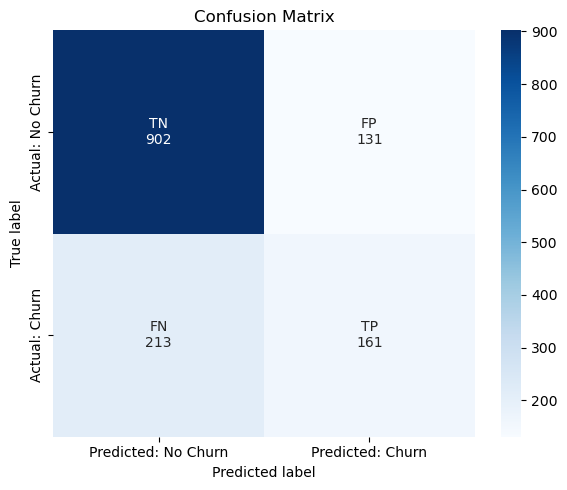

In [43]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2,2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted: No Churn", "Predicted: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

In [44]:
#Accuracy
accuracy= accuracy_score(y_test, y_pred)
accuracy

0.7555081734186212

In [45]:
#Precision

precision = precision_score(y_test, y_pred) 
precision

0.5513698630136986

In [46]:
#Recall
recall = recall_score(y_test, y_pred)
recall

0.4304812834224599

In [47]:
#F1_Score
f1 = f1_score(y_test, y_pred)
f1

0.48348348348348347

## Análisis del Accuracy y comparación con un modelo naive

Dado que aproximadamente el 73,5% de los clientes no abandona el servicio, el `Accuracy` por sí solo no es una métrica suficiente para evaluar el modelo. Al existir un desbalance entre las clases, un modelo podría obtener un Accuracy relativamente alto simplemente por predecir correctamente a la clase mayoritaria, sin identificar adecuadamente a los clientes que sí abandonan.

Por ejemplo, un modelo naive que predijera siempre `Churn = No` tendría un Accuracy de aproximadamente 73,5%, ya que acertaría en todos los clientes que permanecen, pero no detectaría a ninguno de los que abandonan.

Por este motivo, es necesario complementar el Accuracy con métricas como `Precision`, `Recall` y `F1-Score`, que permiten analizar mejor el desempeño del modelo sobre la clase que buscamos detectar.

# P1 Ejercicio 5

## Modelo con tratamiento del desbalance de clases

Como observamos anteriormente, existe un desbalance entre los clientes que abandonan el servicio y los que permanecen. Para tratarlo, decidimos utilizar una técnica de Oversampling en lugar de Undersampling, ya que reducir la clase mayoritaria hasta igualarla con la minoritaria implicaría eliminar una gran cantidad de datos y perder información disponible para el entrenamiento.

En particular, utilizamos ADASYN, que genera nuevas filas de la clase minoritaria para aumentar su representación sin eliminar datos de la clase mayoritaria.

El balanceo se aplica únicamente sobre el conjunto de entrenamiento, manteniendo el conjunto de testeo sin modificaciones para evaluar el modelo sobre la distribución original de los datos.

In [48]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN()

X_train_balanceado, y_train_balanceado = adasyn.fit_resample(X_train_final, y_train)



In [49]:
modeloNuevo = KNeighborsClassifier(n_neighbors = mejor_neighbors) 
modeloNuevo.fit(X_train_balanceado, y_train_balanceado) 
y_predBalanceado = modeloNuevo.predict(X_test_final)


## Comparación de métricas

In [50]:
#Accuracy
accuracyBalanceado= balanced_accuracy_score(y_test, y_predBalanceado)
accuracyBalanceado

0.7152031101977006

In [51]:
#Precision

precisionBalanceado = precision_score(y_test, y_predBalanceado) 
precisionBalanceado

0.43859649122807015

In [52]:
#Recall
recallBalanceado = recall_score(y_test, y_predBalanceado)
recallBalanceado

0.8021390374331551

In [53]:
#F1_Score
f1Balanceado = f1_score(y_test, y_predBalanceado)
f1Balanceado

0.5671077504725898

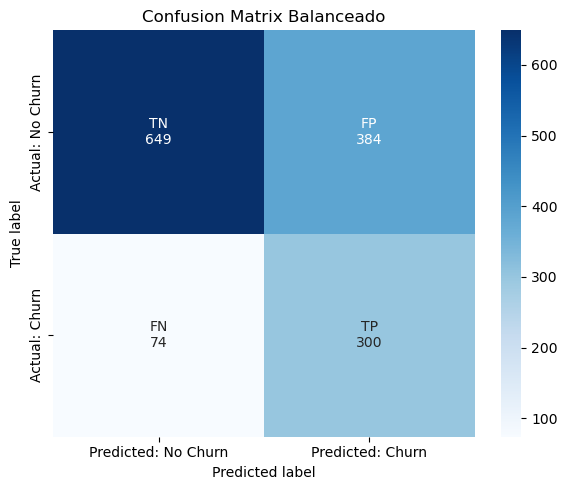

In [64]:
cmBalanceado = confusion_matrix(y_test, y_predBalanceado)
TN, FP, FN, TP = cmBalanceado.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2,2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cmBalanceado,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted: No Churn", "Predicted: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)

plt.title("Confusion Matrix Balanceado")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

## Impacto de FP y FN

**¿Qué impacto económico tiene para la empresa un Falso Positivo?**

Por cada falso positivo, la empresa estaría otorgando un descuento del 50% durante tres meses a un cliente que en realidad no se iba a fugar. Esto implica una pérdida de ingresos innecesaria. 

**¿Qué impacto tiene un Falso Negativo?**

Por cada falso negativo, la empresa no estaría ofreciendo el descuento a un cliente que efectivamente se iba a fugar. En este caso, el costo está asociado a la posible pérdida del cliente y de los ingresos futuros que este podría haber generado.

### Elección de métricas según el costo del descuento

Si el descuento fuera muy costoso para la empresa, priorizaríamos maximizar la Precision, ya que nos interesa que los clientes identificados como posibles abandonos realmente tengan una alta probabilidad de fugarse. Una mayor Precision implica reducir los falsos positivos y, por lo tanto, evitar otorgar descuentos costosos a clientes que no los necesitaban.

En cambio, si el descuento fuera casi gratuito, priorizaríamos maximizar el Recall. En ese caso, sería menos costoso ofrecer el beneficio de más, y resultaría más importante detectar a la mayor cantidad posible de clientes que realmente se van a fugar, reduciendo así los falsos negativos.

# P2 Ejercicio 1


## Definición del nuevo problema predictivo

Elegimos `MonthlyCharges` como nueva variable objetivo. Como se trata de una variable numérica, la transformamos en una variable binaria utilizando la mediana como punto de corte:

- `1`: cargo mensual mayor o igual a la mediana.
- `0`: cargo mensual menor a la mediana.

Elegimos la mediana porque permite dividir a los clientes en dos grupos de tamaño aproximadamente similar, evitando generar un nuevo target desbalanceado.

In [55]:
corte = (churn["MonthlyCharges"]).median()
corte

70.35

In [56]:
MC= churn.copy()
MC["MonthlyCharges"]= MC['MonthlyCharges'].apply(lambda d: 1 if d >= corte else 0)
MC["MonthlyCharges"]

0       0
1       0
2       0
3       0
4       1
       ..
7038    1
7039    1
7040    0
7041    1
7042    1
Name: MonthlyCharges, Length: 7032, dtype: int64

## Entrenamiento del nuevo modelo

Para este nuevo problema utilizamos una Regresión Logística como modelo simple de clasificación binaria. 

In [57]:
#Nuevo Modelo
X_MC = MC.drop(columns='MonthlyCharges')
y_MC = MC['MonthlyCharges']

variables_numericas_MC = ['tenure', 'TotalCharges', 'gender','SeniorCitizen','Partner','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling', 'Churn']

# Train (80%) y test (20%)
X_train_MC, X_test_MC, y_train_MC, y_test_MC = train_test_split(
    X_MC, y_MC, test_size=0.2, random_state=42, stratify=y_MC)

In [58]:
from sklearn.linear_model import LogisticRegression

X_train_MC_final = X_train_MC[variables_numericas_MC].copy()
X_test_MC_final = X_test_MC[variables_numericas_MC].copy()

X_train_MC_final = scaler.fit_transform(X_train_MC_final) 
X_test_MC_final = scaler.transform(X_test_MC_final)

modelo_MC = LogisticRegression() 
modelo_MC.fit(X_train_MC_final, y_train_MC) 
y_pred_MC = modelo_MC.predict(X_test_MC_final)


In [59]:
#Accuracy
accuracy_MC= balanced_accuracy_score(y_test_MC, y_pred_MC)
accuracy_MC

0.944544462629569

In [60]:
#Precision

precision_MC = precision_score(y_test_MC, y_pred_MC) 
precision_MC

0.9372384937238494

In [61]:
#Recall
recall_MC = recall_score(y_test_MC, y_pred_MC)
recall_MC

0.9531914893617022

In [62]:
#F1_Score
f1_MC = f1_score(y_test_MC, y_pred_MC)
f1_MC

0.9451476793248945

**¿Es predecible el nuevo objetivo?**

Sí. A partir de las métricas obtenidas, observamos que la Regresión Logística logra distinguir correctamente entre los clientes con cargos mensuales altos y bajos.

Como el nuevo target fue construido utilizando la mediana, las dos clases tienen tamaños aproximadamente similares, por lo que un modelo que predijera siempre una sola clase tendría un Accuracy cercano al 50%. Dado que nuestro modelo obtuvo métricas considerablemente superiores a ese valor y un buen desempeño general, podemos concluir que `MonthlyCharges` es predecible, en términos de la clasificación propuesta, a partir de las variables utilizadas.

# Conclusiones

